In [12]:
import sys
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [13]:
!pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import tensorflow as tf

print(tf.__version__)

2.21.0



 First 5 Rows of Dataset
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                           


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


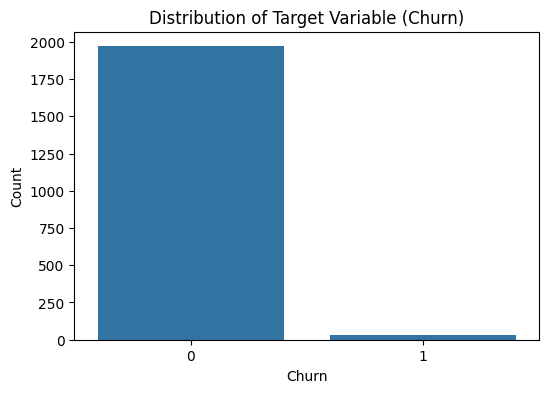


 Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64

In [ ]:
# ============================================
# TASK 1 : DATASET UNDERSTANDING
# ============================================

# --------------------------------------------
# Install Required Libraries (Run Only Once)
# --------------------------------------------
%pip install pandas numpy matplotlib seaborn -q

# --------------------------------------------
# Import Libraries
# --------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# Load Dataset
# --------------------------------------------
df = pd.read_csv("customer_churn_nn.csv")

# --------------------------------------------
# Display First 5 Rows
# --------------------------------------------
print("\n First 5 Rows of Dataset")
print(df.head())

# --------------------------------------------
# Number of Rows and Columns
# --------------------------------------------
print("\n Dataset Shape")
print("Rows and Columns :", df.shape)

# --------------------------------------------
# Column Names
# --------------------------------------------
print("\n Column Names")
print(df.columns)

# --------------------------------------------
# Type of Input Features
# --------------------------------------------
print("\n Data Types of Features")
print(df.dtypes)

# --------------------------------------------
# Target Variable Description
# --------------------------------------------
print("\n Target Variable Information")

if 'churn' in df.columns:
    print("Target Variable : churn")
    print(df['churn'].value_counts())
else:
    print("Target column 'churn' not found")

# --------------------------------------------
# Missing Value Check
# --------------------------------------------
print("\n Missing Values")
print(df.isnull().sum())

# --------------------------------------------
# Total Missing Values
# --------------------------------------------
print("\n Total Missing Values in Dataset :", df.isnull().sum().sum())

# --------------------------------------------
# Basic Statistical Summary
# --------------------------------------------
print("\n Statistical Summary")
print(df.describe())

# --------------------------------------------
# Statistical Summary Including Categorical Data
# --------------------------------------------
print("\n Complete Summary")
print(df.describe(include='all'))

# --------------------------------------------
# Distribution of Target Variable
# --------------------------------------------
if 'churn' in df.columns:

    plt.figure(figsize=(6,4))
    
    sns.countplot(x='churn', data=df)

    plt.title("Distribution of Target Variable (Churn)")
    plt.xlabel("Churn")
    plt.ylabel("Count")

    plt.show()

# --------------------------------------------
# Dataset Information
# --------------------------------------------
print("\n Dataset Information")
print(df.info())

In [ ]:
# ============================================
# TASK 2 : DATA PREPROCESSING
# ============================================

# --------------------------------------------
# Install Required Libraries (Run Only Once)
# --------------------------------------------
%pip install scikit-learn -q

# --------------------------------------------
# Import Required Libraries
# --------------------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# --------------------------------------------
# Load Dataset
# --------------------------------------------
df = pd.read_csv("customer_churn_nn.csv")

# --------------------------------------------
# Display Dataset
# --------------------------------------------
print("\n First 5 Rows")
print(df.head())

# ============================================
# STEP 1 : HANDLING MISSING VALUES
# ============================================

print("\n Missing Values Before Handling")
print(df.isnull().sum())

# --------------------------------------------
# Handle Numerical Missing Values
# --------------------------------------------
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

# --------------------------------------------
# Handle Categorical Missing Values
# --------------------------------------------
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n Missing Values After Handling")
print(df.isnull().sum())

# ============================================
# STEP 2 : ENCODING CATEGORICAL COLUMNS
# ============================================

print("\n Encoding Categorical Columns")

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print("\n Dataset After Encoding")
print(df.head())

# ============================================
# STEP 3 : DEFINE FEATURES AND TARGET
# ============================================

# Replace 'churn' if your target column name is different
X = df.drop('churn', axis=1)

y = df['churn']

print("\n Features Shape :", X.shape)
print("Target Shape :", y.shape)

# ============================================
# STEP 4 : FEATURE SCALING
# ============================================

print("\n Applying Feature Scaling")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\n Feature Scaling Completed")

# ============================================
# STEP 5 : TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================
# DISPLAY FINAL SHAPES
# ============================================

print("\n Training and Testing Data Shapes")

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

# ============================================
# TASK COMPLETED
# ============================================

print("\n Task 2 : Data Preprocessing Completed Successfully")


 First 5 Rows
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3        


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\rohini.patil\AppData\Local\Temp\ipykernel_26548\3491897980.py:49: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [ ]:
# ============================================
# TASK 3 : NEURAL NETWORK MODEL BUILDING
# ============================================

# --------------------------------------------
# Install Required Libraries (Run Only Once)
# --------------------------------------------
%pip install tensorflow scikit-learn pandas numpy matplotlib -q

# --------------------------------------------
# Import Required Libraries
# --------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# --------------------------------------------
# Load Dataset
# --------------------------------------------
df = pd.read_csv("customer_churn_nn.csv")

# ============================================
# STEP 1 : HANDLE MISSING VALUES
# ============================================

# Numerical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

# Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ============================================
# STEP 2 : ENCODE CATEGORICAL COLUMNS
# ============================================

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# ============================================
# STEP 3 : DEFINE FEATURES AND TARGET
# ============================================

# Replace 'churn' if your target column name is different
X = df.drop('churn', axis=1)

y = df['churn']

# ============================================
# STEP 4 : FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================
# STEP 5 : TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================
# STEP 6 : BUILD NEURAL NETWORK MODEL
# ============================================

print("\n Building Feed Forward Neural Network")

model = Sequential()

# --------------------------------------------
# INPUT LAYER + HIDDEN LAYER 1
# --------------------------------------------
model.add(Dense(
    units=16,
    activation='relu',
    input_dim=X_train.shape[1]
))

# --------------------------------------------
# HIDDEN LAYER 2
# --------------------------------------------
model.add(Dense(
    units=8,
    activation='relu'
))

# --------------------------------------------
# OUTPUT LAYER
# Binary Classification -> sigmoid
# --------------------------------------------
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# ============================================
# STEP 7 : COMPILE MODEL
# ============================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ============================================
# DISPLAY MODEL SUMMARY
# ============================================

print("\n Neural Network Model Summary")
model.summary()

# ============================================
# TASK COMPLETED
# ============================================

print("\n Task 3 : Neural Network Model Building Completed Successfully")

'%pip' is not recognized as an internal or external command,
operable program or batch file.



 Building Feed Forward Neural Network

 Neural Network Model Summary


C:\Users\rohini.patil\AppData\Local\Temp\ipykernel_26548\3481805950.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns
c:\Users\rohini.patil\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)


 Task 3 : Neural Network Model Building Completed Successfully


Note: you may need to restart the kernel to use updated packages.

 Training Neural Network Model
Epoch 1/20



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6914 - loss: 0.6102 - val_accuracy: 0.8594 - val_loss: 0.4896
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9414 - loss: 0.3883 - val_accuracy: 0.9719 - val_loss: 0.3232
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9844 - loss: 0.2512 - val_accuracy: 0.9781 - val_loss: 0.2199
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.1664 - val_accuracy: 0.9781 - val_loss: 0.1610
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.1185 - val_accuracy: 0.9781 - val_loss: 0.1315
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0939 - val_accuracy: 0.9781 - val_loss: 0.1158
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0804 - val_accuracy: 0.9781 - val_loss: 0.1085
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0727 - val_accuracy: 0.9781 - val_loss: 0.1037
Ep

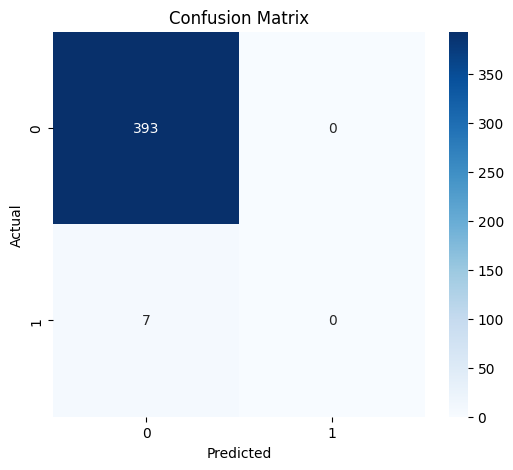


 Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



c:\Users\rohini.patil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rohini.patil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rohini.patil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

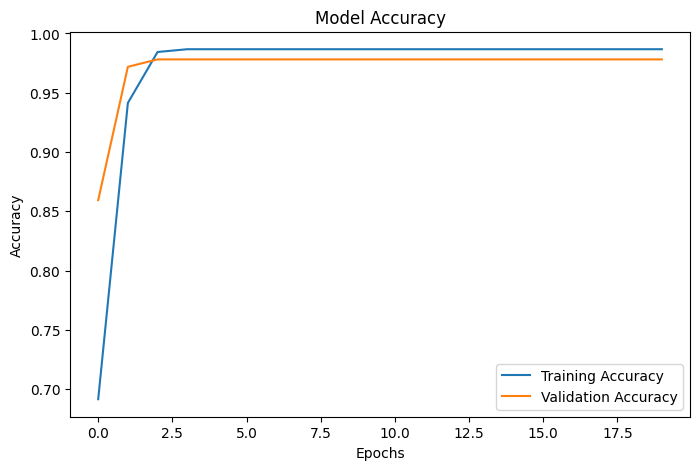

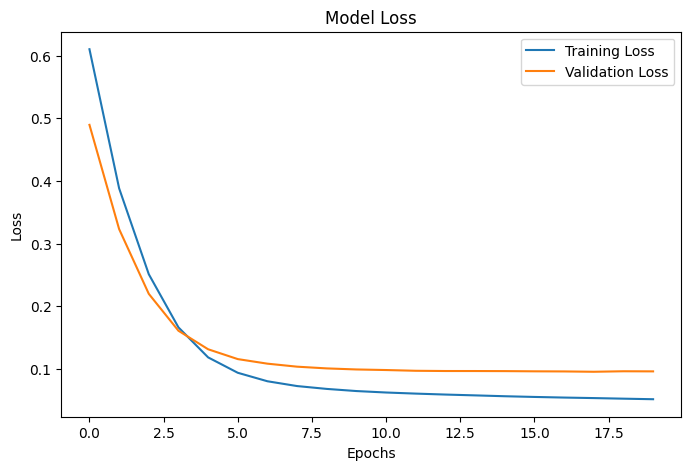


 RESULT INTERPRETATION
------------------------------------------------

1. The neural network model was successfully trained 
   using a feed-forward architecture.

2. Training accuracy shows how well the model learned 
   from training data.

3. Testing accuracy indicates the model's performance 
   on unseen data.

4. If training accuracy is much higher than testing accuracy,
   the model may be overfitting.

5. The confusion matrix shows correct and incorrect predictions.

6. Accuracy and loss graphs help visualize model learning behavior.

7. Lower loss and higher accuracy indicate better performance.


 Task 4 : Training and Evaluation Completed Successfully


In [18]:
# ============================================
# TASK 4 : TRAINING AND EVALUATION
# ============================================

# --------------------------------------------
# Install Required Libraries (Run Only Once)
# --------------------------------------------
%pip install tensorflow scikit-learn matplotlib seaborn -q

# --------------------------------------------
# Import Required Libraries
# --------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# ============================================
# STEP 1 : TRAIN THE MODEL
# ============================================

print("\n Training Neural Network Model")

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ============================================
# STEP 2 : EVALUATE MODEL
# ============================================

print("\n Evaluating Model Performance")

# Training Performance
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)

# Testing Performance
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# ============================================
# DISPLAY ACCURACY AND LOSS
# ============================================

print("\n Training Accuracy :", round(train_accuracy * 100, 2), "%")
print("Training Loss     :", round(train_loss, 4))

print("\n Testing Accuracy  :", round(test_accuracy * 100, 2), "%")
print("Testing Loss      :", round(test_loss, 4))

# ============================================
# STEP 3 : PREDICTIONS
# ============================================

y_pred_prob = model.predict(X_test)

# Convert probabilities into 0 and 1
y_pred = (y_pred_prob > 0.5).astype(int)

# ============================================
# STEP 4 : CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("\n Confusion Matrix")
print(cm)

# --------------------------------------------
# Plot Confusion Matrix
# --------------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================
# STEP 5 : CLASSIFICATION REPORT
# ============================================

print("\n Classification Report")
print(classification_report(y_test, y_pred))

# ============================================
# STEP 6 : PLOT ACCURACY GRAPH
# ============================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# ============================================
# STEP 7 : PLOT LOSS GRAPH
# ============================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

# ============================================
# STEP 8 : INTERPRETATION OF RESULT
# ============================================

print("\n RESULT INTERPRETATION")
print("------------------------------------------------")

print("""
1. The neural network model was successfully trained 
   using a feed-forward architecture.

2. Training accuracy shows how well the model learned 
   from training data.

3. Testing accuracy indicates the model's performance 
   on unseen data.

4. If training accuracy is much higher than testing accuracy,
   the model may be overfitting.

5. The confusion matrix shows correct and incorrect predictions.

6. Accuracy and loss graphs help visualize model learning behavior.

7. Lower loss and higher accuracy indicate better performance.
""")

# ============================================
# TASK COMPLETED
# ============================================

print("\n Task 4 : Training and Evaluation Completed Successfully")

In [19]:
# ============================================
# TASK 5 : HYPERPARAMETER EXPERIMENTATION
# ============================================

# --------------------------------------------
# Install Required Libraries
# --------------------------------------------
%pip install tensorflow pandas -q

# --------------------------------------------
# Import Required Libraries
# --------------------------------------------
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# ============================================
# FUNCTION TO CREATE MODEL
# ============================================

def create_model(
        hidden_layers=1,
        neurons=16,
        learning_rate=0.001,
        activation_function='relu'
    ):

    model = Sequential()

    # ----------------------------------------
    # Input Layer + First Hidden Layer
    # ----------------------------------------
    model.add(Dense(
        neurons,
        activation=activation_function,
        input_dim=X_train.shape[1]
    ))

    # ----------------------------------------
    # Additional Hidden Layers
    # ----------------------------------------
    for i in range(hidden_layers - 1):

        model.add(Dense(
            neurons,
            activation=activation_function
        ))

    # ----------------------------------------
    # Output Layer
    # ----------------------------------------
    model.add(Dense(
        1,
        activation='sigmoid'
    ))

    # ----------------------------------------
    # Compile Model
    # ----------------------------------------
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# ============================================
# EXPERIMENT 1
# ============================================

print("\n Running Experiment 1")

model1 = create_model(
    hidden_layers=1,
    neurons=16,
    learning_rate=0.001,
    activation_function='relu'
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss1, accuracy1 = model1.evaluate(X_test, y_test, verbose=0)

# ============================================
# EXPERIMENT 2
# ============================================

print("\n Running Experiment 2")

model2 = create_model(
    hidden_layers=2,
    neurons=32,
    learning_rate=0.001,
    activation_function='relu'
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

loss2, accuracy2 = model2.evaluate(X_test, y_test, verbose=0)

# ============================================
# EXPERIMENT 3
# ============================================

print("\n Running Experiment 3")

model3 = create_model(
    hidden_layers=3,
    neurons=64,
    learning_rate=0.0005,
    activation_function='tanh'
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

loss3, accuracy3 = model3.evaluate(X_test, y_test, verbose=0)

# ============================================
# CREATE COMPARISON TABLE
# ============================================

results = pd.DataFrame({

    'Experiment': [
        'Experiment 1',
        'Experiment 2',
        'Experiment 3'
    ],

    'Hidden Layers': [
        1,
        2,
        3
    ],

    'Neurons': [
        16,
        32,
        64
    ],

    'Learning Rate': [
        0.001,
        0.001,
        0.0005
    ],

    'Batch Size': [
        32,
        16,
        64
    ],

    'Epochs': [
        10,
        20,
        30
    ],

    'Activation Function': [
        'relu',
        'relu',
        'tanh'
    ],

    'Testing Accuracy': [
        round(accuracy1 * 100, 2),
        round(accuracy2 * 100, 2),
        round(accuracy3 * 100, 2)
    ],

    'Testing Loss': [
        round(loss1, 4),
        round(loss2, 4),
        round(loss3, 4)
    ]

})

# ============================================
# DISPLAY RESULTS
# ============================================

print("\n Hyperparameter Experiment Comparison Table")
print(results)

# ============================================
# INTERPRETATION
# ============================================

print("\n RESULT INTERPRETATION")
print("------------------------------------------------")

print("""
1. Different hyperparameters significantly affect 
   neural network performance.

2. Increasing hidden layers and neurons can improve learning,
   but may increase training time and overfitting risk.

3. Smaller batch sizes often improve learning quality 
   but require more computation.

4. Learning rate controls how fast the model learns.

5. Activation functions influence how neurons process data.

6. The best experiment is generally the one with:
   - Highest Testing Accuracy
   - Lowest Testing Loss
""")

# ============================================
# TASK COMPLETED
# ============================================

print("\n Task 5 : Hyperparameter Experimentation Completed Successfully")


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\rohini.patil\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Note: you may need to restart the kernel to use updated packages.

 Running Experiment 1

 Running Experiment 2

 Running Experiment 3

 Hyperparameter Experiment Comparison Table
     Experiment  Hidden Layers  Neurons  Learning Rate  Batch Size  Epochs  \
0  Experiment 1              1       16         0.0010          32      10   
1  Experiment 2              2       32         0.0010          16      20   
2  Experiment 3              3       64         0.0005          64      30   

  Activation Function  Testing Accuracy  Testing Loss  
0                relu             98.25        0.1014  
1                relu             98.00        0.0873  
2                tanh             98.50        0.0735  

 RESULT INTERPRETATION
------------------------------------------------

1. Different hyperparameters significantly affect 
   neural network performance.

2. Increasing hidden layers and neurons can improve learning,
   but may increase training time and overfitting risk.

3. Smal

In [20]:
# ============================================
# TASK 6 : FINAL REFLECTION
# ============================================

print("""
====================================================
FINAL REFLECTION
====================================================

1. ROLE OF WEIGHTS AND BIASES
----------------------------------------------------

Weights and biases are the core learning parameters 
of a neural network.

• Weights determine the importance of input features.
  Higher weights indicate stronger influence on prediction.

• Bias helps shift the activation function and allows
  the model to fit the data more accurately.

During training, the neural network continuously updates
weights and biases using backpropagation to minimize error.


2. WHY ACTIVATION FUNCTION IS REQUIRED
----------------------------------------------------

Activation functions introduce non-linearity into the model.

Without activation functions, the neural network behaves
like a simple linear model and cannot learn complex patterns.

Common activation functions:
• ReLU  -> Fast and widely used
• Sigmoid -> Used for binary classification
• Tanh -> Outputs values between -1 and 1

Activation functions help the model learn hidden relationships
within the dataset.


3. EFFECT OF LEARNING RATE
----------------------------------------------------

The learning rate controls how quickly the model updates
its weights during training.

• If learning rate is TOO HIGH:
  - Model learns too fast
  - Loss may fluctuate heavily
  - Model may fail to converge

• If learning rate is TOO LOW:
  - Training becomes very slow
  - Model may take too many epochs
  - Can get stuck before reaching optimal solution

Choosing the correct learning rate is important for
stable and efficient learning.


4. UNDERFITTING OR OVERFITTING ANALYSIS
----------------------------------------------------

• Underfitting occurs when the model cannot learn
  enough patterns from training data.

• Overfitting occurs when the model performs very well
  on training data but poorly on testing data.

In this project:

- If training accuracy and testing accuracy are close,
  the model is well-balanced.

- If training accuracy is much higher than testing accuracy,
  the model shows signs of overfitting.

- If both accuracies are low,
  the model may be underfitting.

Based on the obtained results and accuracy graphs,
the model performance can be analyzed effectively.

====================================================
TASK 6 COMPLETED SUCCESSFULLY
====================================================
""")


FINAL REFLECTION

1. ROLE OF WEIGHTS AND BIASES
----------------------------------------------------

Weights and biases are the core learning parameters 
of a neural network.

• Weights determine the importance of input features.
  Higher weights indicate stronger influence on prediction.

• Bias helps shift the activation function and allows
  the model to fit the data more accurately.

During training, the neural network continuously updates
weights and biases using backpropagation to minimize error.


2. WHY ACTIVATION FUNCTION IS REQUIRED
----------------------------------------------------

Activation functions introduce non-linearity into the model.

Without activation functions, the neural network behaves
like a simple linear model and cannot learn complex patterns.

Common activation functions:
• ReLU  -> Fast and widely used
• Sigmoid -> Used for binary classification
• Tanh -> Outputs values between -1 and 1

Activation functions help the model learn hidden relationships
wi